# 15_feature_visualisation

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT764  
**Prepared by:** Subathira Thinakaran
**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Feature Visualisation (Week 6 of 8)

## Objective
This notebook analyses the validated modelling dataset to understand relationships between crash, weather, and mobility variables.

The aim is to:
- visualise important numeric feature relationships
- generate correlation heatmaps
- review relationships between crash, weather, and mobility variables
- identify modelling-ready features
- note any features requiring encoding, grouping, or exclusion before baseline modelling

In [1]:
# -----------------------------
# 1. Import libraries
# -----------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Upload files (optional)
# -----------------------------
from google.colab import files
uploaded = files.upload()

Saving validated_model_dataset.csv to validated_model_dataset.csv


## Load Validated Dataset

This section loads the final validated dataset produced after dataset integration and validation.

In [3]:
# -----------------------------
# 2. Load validated dataset
# -----------------------------
DATA_DIR = Path("data/final")

validated_file = DATA_DIR / "validated_model_dataset.csv"

# Fallback for Colab/manual upload
if not validated_file.exists():
    print("Using uploaded file in current directory...")
    validated_file = Path("validated_model_dataset.csv")

df = pd.read_csv(validated_file)

print("Validated dataset shape:", df.shape)
df.head()

Using uploaded file in current directory...
Validated dataset shape: (151947, 106)


,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,...,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089005
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,Serious injury accident,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303805,0.123037


### Observation

The dataset contains crash, weather, mobility, and temporal features prepared during integration and validation stages. This dataset will be used for feature analysis and modelling preparation.

In [4]:
# -----------------------------
# 3. Quick validation check
# -----------------------------
print("Missing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["SEVERITY"].value_counts())

Missing values (top 10):
speed_zone_numeric      11765
DIVIDED                  6688
RMA                      6688
gust_to_wind_ratio       2265
Total Rainfall (mm)      1771
max gust speed(km/h)     1396
Time of maximum gust     1248
Max temperature (°C)     1248
max pressure (hPa)       1248
Min temperature (°C)     1248
dtype: int64

Duplicate rows: 0

Target distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64


### Observation

The dataset shows some missing values in features such as speed zone and weather variables, which will require handling before modelling.

No duplicate records were found, confirming data integrity.

The target variable `SEVERITY` is highly imbalanced, with fatal accidents representing a very small proportion of the dataset. This imbalance may lead to biased model predictions and must be addressed during modelling.

## Select Important Features

This section selects key crash, weather, mobility, and temporal variables for visual analysis.

In [5]:
# -----------------------------
# 4. Select important features
# -----------------------------
important_features = [
    "SEVERITY",
    "speed_zone_numeric",
    "rush_hour",
    "weekend_flag",
    "hour_of_day",
    "pedestrian_density",
    "bicycle_density",
    "Total Rainfall (mm)",
    "Max temperature (°C)",
    "Min temperature (°C)",
    "Max Humidity (%)",
    "max wind speed (km/h)"
]

selected_features = [col for col in important_features if col in df.columns]

feature_df = df[selected_features].copy()

print("Selected features:")
print(selected_features)

feature_df.head()

Selected features:
['SEVERITY', 'speed_zone_numeric', 'rush_hour', 'weekend_flag', 'hour_of_day', 'pedestrian_density', 'bicycle_density', 'Total Rainfall (mm)', 'Max temperature (°C)', 'Min temperature (°C)', 'Max Humidity (%)', 'max wind speed (km/h)']


,SEVERITY,speed_zone_numeric,rush_hour,weekend_flag,hour_of_day,pedestrian_density,bicycle_density,Total Rainfall (mm),Max temperature (°C),Min temperature (°C),Max Humidity (%),max wind speed (km/h)
0,Serious injury accident,50.0,0,0,22,0.115603,0.026178,0.0,17.3,13.5,98.0,24.0
1,Other injury accident,40.0,0,0,2,0.011888,0.000000,3.6,21.3,11.1,100.0,20.0
2,Serious injury accident,100.0,0,1,23,0.269190,0.005236,0.0,23.8,20.3,74.0,28.0
3,Serious injury accident,100.0,1,0,15,0.615111,0.089005,4.0,37.1,20.0,96.0,28.0
4,Serious injury accident,50.0,0,0,22,0.303805,0.123037,0.0,29.3,20.3,64.0,13.0


### Observation

Features were selected to represent mobility, weather, temporal, and traffic conditions while avoiding unnecessary complexity.

## Prepare data for Correlation

Correlation analysis requires numeric features. This step selects only numeric columns from the chosen feature set.

In [6]:
# -----------------------------
# 5. Prepare data for correlation
# -----------------------------
feature_df_corr = feature_df.copy()

# Convert SEVERITY to numeric
severity_map = {
    "Other injury accident": 1,
    "Serious injury accident": 2,
    "Fatal accident": 3
}

feature_df_corr["SEVERITY"] = feature_df_corr["SEVERITY"].map(severity_map)

# Select numeric only
numeric_df = feature_df_corr.select_dtypes(include=["number"])

print(numeric_df.head())

   SEVERITY  speed_zone_numeric  rush_hour  weekend_flag  hour_of_day  \
0         2                50.0          0             0           22   
1         1                40.0          0             0            2   
2         2               100.0          0             1           23   
3         2               100.0          1             0           15   
4         2                50.0          0             0           22   

   pedestrian_density  bicycle_density  Total Rainfall (mm)  \
0            0.115603         0.026178                  0.0   
1            0.011888         0.000000                  3.6   
2            0.269190         0.005236                  0.0   
3            0.615111         0.089005                  4.0   
4            0.303805         0.123037                  0.0   

   Max temperature (°C)  Min temperature (°C)  Max Humidity (%)  \
0                  17.3                  13.5              98.0   
1                  21.3                  11.1   

### Observation

Numeric features were selected for correlation analysis. These variables will be used to identify relationships between crash-related, weather-related, and mobility-related factors.

## Correlation Heatmap

This section visualises the relationships between selected numeric features using a correlation heatmap.

The target variable `SEVERITY` has been converted into a numeric scale to allow correlation analysis. Only numeric features are included to ensure meaningful computation of correlations.

The heatmap helps identify:
- features that are related to crash severity
- relationships between mobility, weather, and traffic variables
- potential redundancy between features

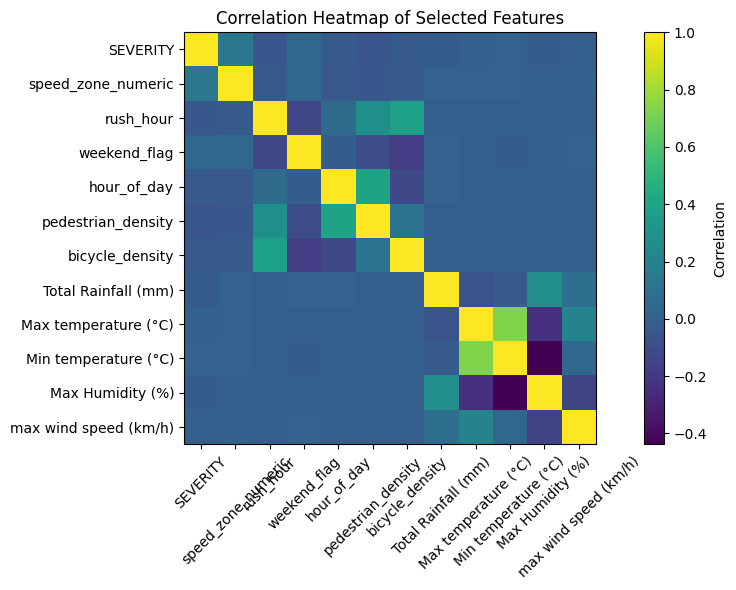

In [7]:
# -----------------------------
# 6. Correlation heatmap
# -----------------------------
# Drop missing values for cleaner correlation
numeric_df_clean = numeric_df.dropna()

# Compute correlation matrix
corr_matrix = numeric_df_clean.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows weak relationships between individual features and crash severity. This indicates that accident severity is influenced by a combination of multiple factors rather than a single dominant predictor.

Strong correlations among temperature variables suggest redundancy. This suggests that machine learning models will need to capture non-linear relationships and feature interactions rather than relying on simple correlations.

## Target Variable Distribution

This section reviews the distribution of the target variable, `SEVERITY`, to understand class balance before modelling.

SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64


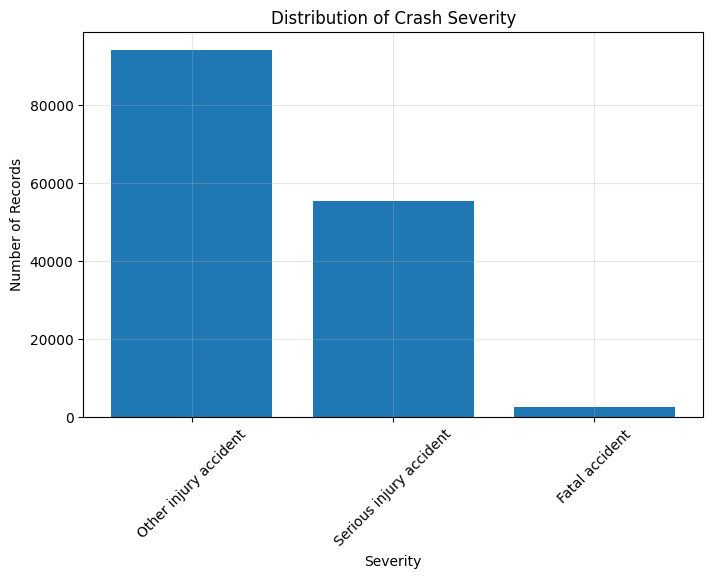

In [8]:
# -----------------------------
# 7. Target variable distribution
# -----------------------------
if "SEVERITY" in df.columns:
    severity_counts = df["SEVERITY"].value_counts()

    print(severity_counts)

    plt.figure(figsize=(8, 5))
    plt.bar(severity_counts.index.astype(str), severity_counts.values)

    plt.xlabel("Severity")
    plt.ylabel("Number of Records")
    plt.title("Distribution of Crash Severity")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    plt.show()
else:
    print("SEVERITY column not found.")

### Observation

The target variable is highly imbalanced. Fatal accidents are rare compared to other categories. This imbalance may lead to biased model predictions and must be handled using techniques such as resampling or class weighting.

## Mobility Feature Distributions

This section reviews the distribution of the engineered mobility features: `pedestrian_density` and `bicycle_density`.

These features represent relative mobility intensity and help identify whether pedestrian and bicycle activity varies meaningfully across the validated dataset.

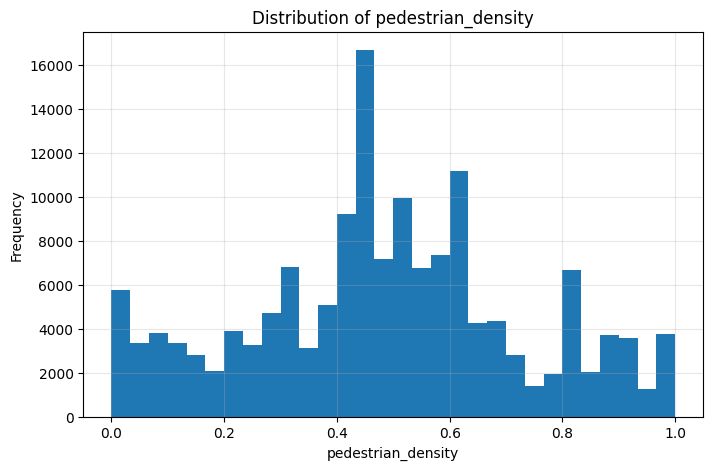

pedestrian_density summary:
count    151947.000000
mean          0.483836
std           0.243216
min           0.000000
25%           0.320301
50%           0.470932
75%           0.626744
max           1.000000
Name: pedestrian_density, dtype: float64



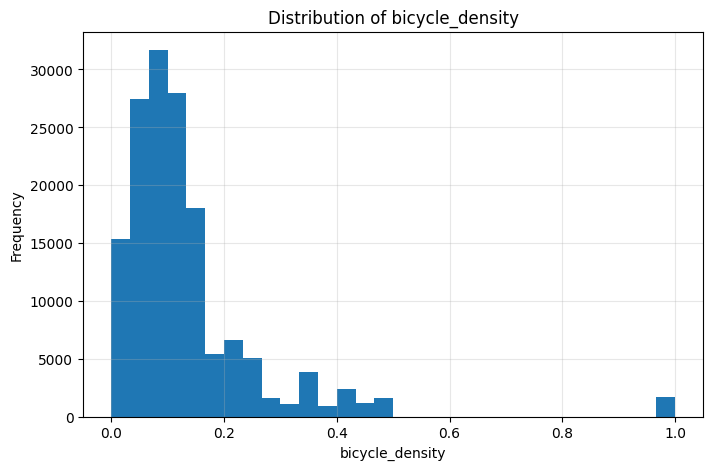

bicycle_density summary:
count    151947.000000
mean          0.136708
std           0.133885
min           0.000000
25%           0.062827
50%           0.102094
75%           0.151832
max           1.000000
Name: bicycle_density, dtype: float64



In [9]:
# -----------------------------
# 8. Mobility feature distributions
# -----------------------------
mobility_cols = [
    col for col in ["pedestrian_density", "bicycle_density"]
    if col in df.columns
]

for col in mobility_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True, alpha=0.3)

    plt.show()

    print(f"{col} summary:")
    print(df[col].describe())
    print()

### Observation

Pedestrian density is well distributed, indicating strong variability across locations and times. Bicycle density is skewed towards lower values, indicating generally low activity.

Pedestrian density is likely a stronger predictor, while bicycle density provides contextual support.

## Mobility Features vs Crash Severity

This section analyses how mobility intensity varies across different crash severity categories.

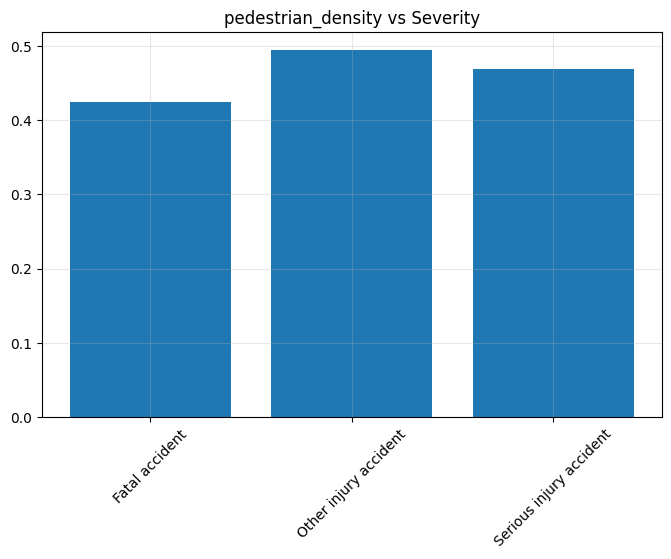

SEVERITY
Fatal accident             0.424741
Other injury accident      0.494052
Serious injury accident    0.469152
Name: pedestrian_density, dtype: float64


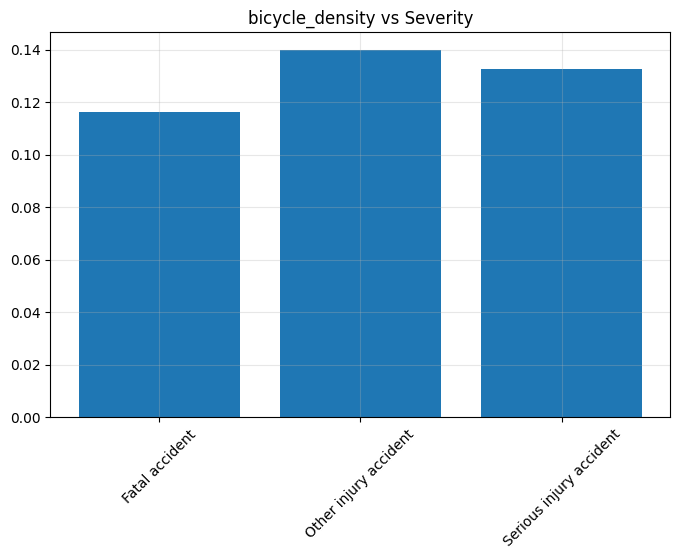

SEVERITY
Fatal accident             0.116239
Other injury accident      0.139713
Serious injury accident    0.132531
Name: bicycle_density, dtype: float64


In [15]:
# -----------------------------
# 9. Mobility Features vs Crash Severity
# -----------------------------

for col in ["pedestrian_density", "bicycle_density"]:
    avg = df.groupby("SEVERITY")[col].mean()

    plt.figure(figsize=(8, 5))
    plt.bar(avg.index.astype(str), avg.values)
    plt.title(f"{col} vs Severity")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(avg)

### Observation

Mobility features show a clear pattern where lower activity levels are associated with more severe crashes.

Fatal accidents tend to occur in low-activity areas such as highways, while less severe accidents occur in more active and regulated environments.

This highlights mobility as an important contextual feature.

## Weather Features vs Crash Severity

This section analyses how environmental conditions vary across crash severity levels.

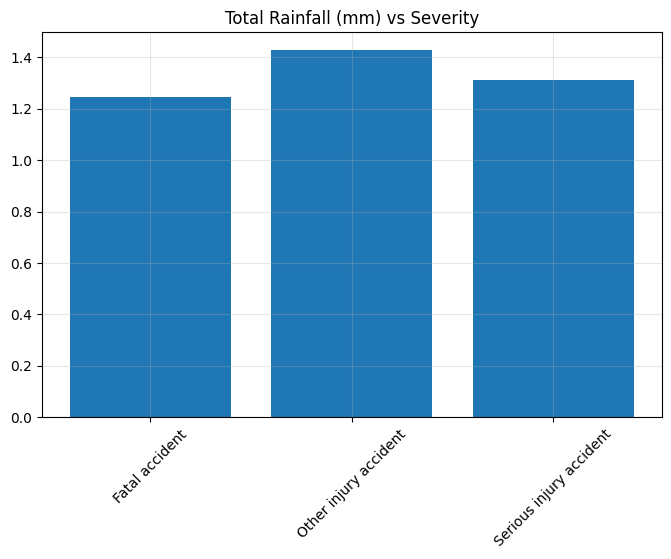

SEVERITY
Fatal accident             1.246426
Other injury accident      1.426780
Serious injury accident    1.310490
Name: Total Rainfall (mm), dtype: float64


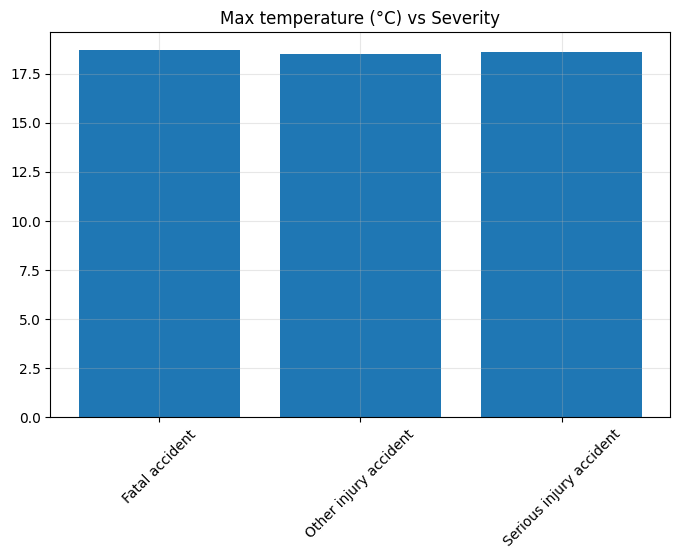

SEVERITY
Fatal accident             18.680817
Other injury accident      18.506366
Serious injury accident    18.627401
Name: Max temperature (°C), dtype: float64


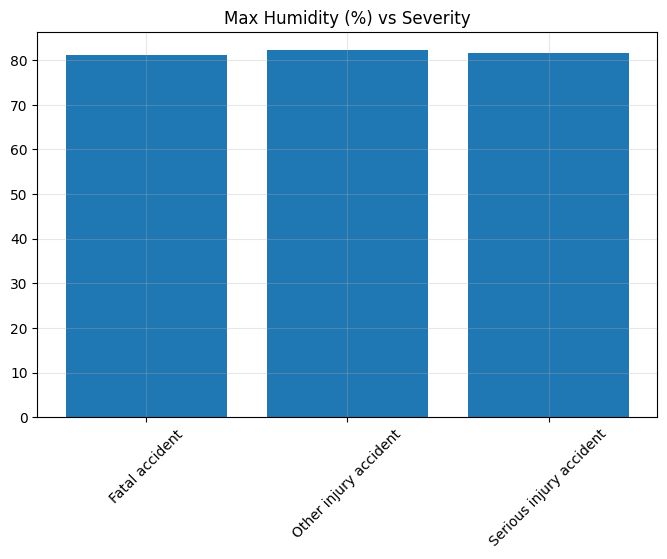

SEVERITY
Fatal accident             81.137365
Other injury accident      82.192732
Serious injury accident    81.721373
Name: Max Humidity (%), dtype: float64


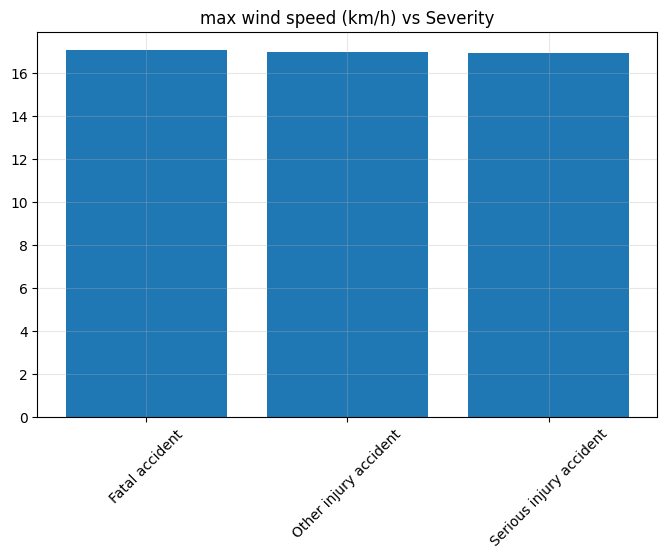

SEVERITY
Fatal accident             17.068482
Other injury accident      16.994122
Serious injury accident    16.951558
Name: max wind speed (km/h), dtype: float64


In [16]:
# -----------------------------
# 10. Weather Features vs Crash Severity
# -----------------------------

weather_cols = [
    "Total Rainfall (mm)",
    "Max temperature (°C)",
    "Max Humidity (%)",
    "max wind speed (km/h)"
]

weather_cols = [col for col in weather_cols if col in df.columns]

for col in weather_cols:
    avg = df.groupby("SEVERITY")[col].mean()

    plt.figure(figsize=(8, 5))
    plt.bar(avg.index.astype(str), avg.values)
    plt.title(f"{col} vs Severity")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(avg)

### Observation

Weather variables show minimal variation across severity levels. Rainfall shows a slight inverse relationship, while temperature, humidity, and wind speed have negligible impact.

Weather is not a strong standalone predictor but may contribute when combined with other features.

## Temporal Feature Relationships

This section reviews accident patterns across temporal variables such as rush hour, weekend flag, and hour of day.

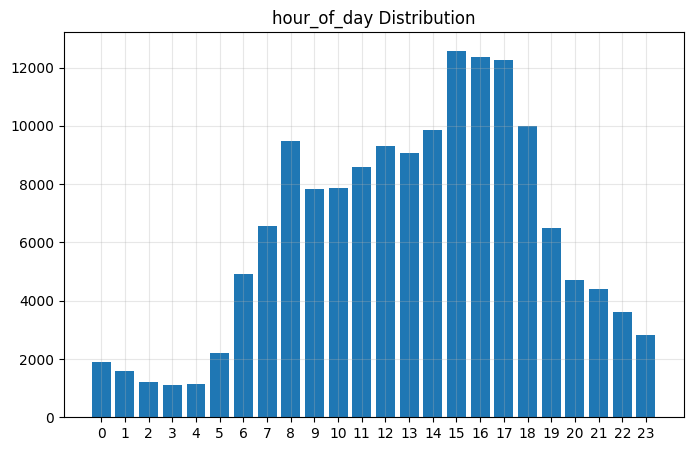

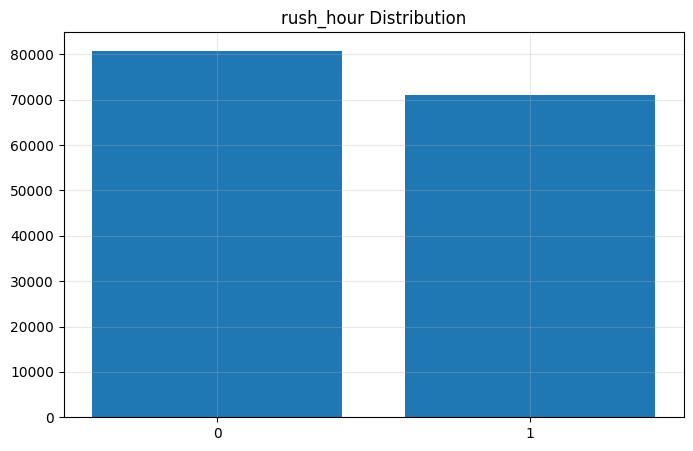

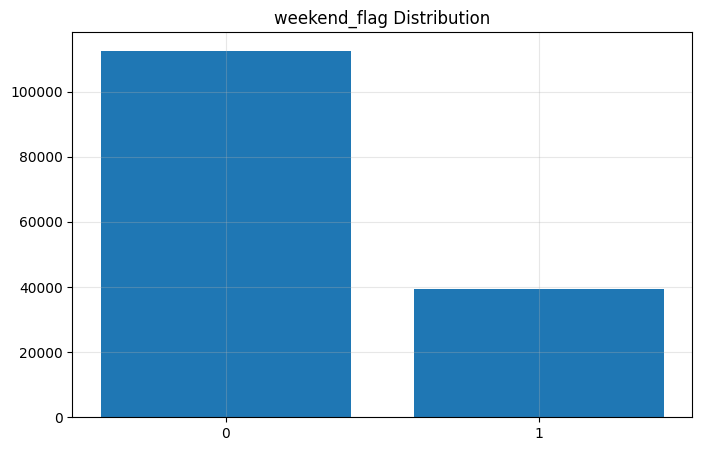

In [17]:
# -----------------------------
# 11. Temporal Feature Relationships
# -----------------------------

for col in ["hour_of_day", "rush_hour", "weekend_flag"]:
    counts = df[col].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution")
    plt.grid(True, alpha=0.3)
    plt.show()

### Observation

Temporal features capture behavioural patterns such as peak traffic hours and weekend activity. These factors influence traffic flow and indirectly affect crash outcomes.

## Modelling Readiness Notes

This section summarises feature considerations before starting baseline modelling.

In [18]:
# -----------------------------
# 12. Modelling readiness notes
# -----------------------------
print("Potential numeric features for baseline modelling:")
print(list(numeric_df.columns))

print("\nPotential categorical features requiring encoding:")
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(categorical_cols[:20])

print("\nTarget variable:")
if "SEVERITY" in df.columns:
    print("SEVERITY")
    print(df["SEVERITY"].value_counts())
else:
    print("SEVERITY column not found.")

Potential numeric features for baseline modelling:
['SEVERITY', 'speed_zone_numeric', 'rush_hour', 'weekend_flag', 'hour_of_day', 'pedestrian_density', 'bicycle_density', 'Total Rainfall (mm)', 'Max temperature (°C)', 'Min temperature (°C)', 'Max Humidity (%)', 'max wind speed (km/h)']

Potential categorical features requiring encoding:
['ACCIDENT_NO', 'date', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME', 'RMA', 'DIVIDED', 'STAT_DIV_NAME', 'day_of_week']

Target variable:
SEVERITY
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64


### Feature Selection Insights

Based on the visual analysis:

- Crash severity is influenced by multiple factors rather than a single dominant feature.
- Mobility features show meaningful patterns, where lower activity is associated with higher severity.
- Weather features show weak relationships and should be used cautiously.
- Temporal features such as hour of day and rush hour provide important behavioural context.

### Data Preparation Considerations

- Handle missing values in features such as speed_zone_numeric and weather variables
- Address class imbalance in the target variable `SEVERITY`
- Encode categorical variables before modelling
- Remove redundant features (e.g., highly correlated temperature variables)

### Modelling Strategy

- Use a combination of mobility, temporal, and selected weather features
- Consider grouping severity classes for baseline modelling
- Evaluate model performance carefully due to class imbalance